# TP3 — Reconnaissance de Figures avec un MLP
### Université de Yaoundé I — L3 Informatique | INF372
---

##  Objectif du TP

Ce TP a pour objectif d'implémenter un **Perceptron Multicouche (MLP)** pour la reconnaissance de chiffres manuscrits (0 à 9) issus du dataset **MNIST**.

### Architecture choisie :
| Couche | Taille | Activation |
|---|---|---|
| Entrée | 1024 neurones (32×32 pixels) | — |
| Cachée | 64 neurones | ReLU |
| Sortie | 10 neurones (classes 0–9) | Softmax |

### Méthode d'optimisation : **Descente de Gradient Stochastique (SGD)**

### Livrables attendus :
- Prétraitement et analyse des données
- Entraînement du MLP avec visualisation de la convergence
- Heatmap des poids (ce que le réseau apprend)
- Heatmap des activations (comment le réseau distingue les chiffres)
- Évaluation des performances

## 1.  Importation des bibliothèques

In [3]:
# ─── Bibliothèques standard ───────────────────────────────────────────────────
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from PIL import Image
from tqdm import tqdm
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from IPython.display import display

# ─── Reproductibilité ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Bibliothèques importées avec succès.")

 Bibliothèques importées avec succès.


## 2. Chargement des données

Les images sont stockées dans `images_1000/train/` et `images_1000/test/`.  
Le label de chaque image est extrait directement depuis son nom de fichier.  
Exemple : `train_00000_label_5.png` → label = **5**

Chaque image de 32×32 pixels est **aplatie en un vecteur de 1024 valeurs**,  
normalisée entre 0 et 1 (division par 255).

In [4]:
def load_dataset(folder_path):
    """
    Charge toutes les images PNG d'un dossier.
    Retourne X (tableau d'images aplaties) et y (labels).
    """
    X, y = [], []
    files = sorted(os.listdir(folder_path))

    for fname in tqdm(files, desc=f"Chargement {os.path.basename(folder_path)}"):
        if not fname.endswith(".png"):
            continue

        # Extraction du label depuis le nom du fichier
        match = re.search(r"label_(\d+)", fname)
        if match is None:
            continue
        label = int(match.group(1))

        # Chargement et prétraitement de l'image
        img_path = os.path.join(folder_path, fname)
        img = Image.open(img_path).convert("L")          # Niveaux de gris
        img = img.resize((32, 32))                        # Sécurité : 32×32
        img_array = np.array(img, dtype=np.float32) / 255.0  # Normalisation
        X.append(img_array.flatten())                     # Aplatissement → 1024
        y.append(label)

    return np.array(X), np.array(y)


# ─── Chemins ──────────────────────────────────────────────────────────────────
BASE_DIR   = "images_1000"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")

# ─── Chargement ───────────────────────────────────────────────────────────────
X_train, y_train = load_dataset(TRAIN_DIR)
X_test,  y_test  = load_dataset(TEST_DIR)

print(f"\nTrain : {X_train.shape[0]} images — shape : {X_train.shape}")
print(f"Test  : {X_test.shape[0]}  images — shape : {X_test.shape}")

Chargement test: 100%|██████████████████| 10000/10000 [00:01<00:00, 5402.63it/s]


Train : 60000 images — shape : (60000, 1024)
Test  : 10000  images — shape : (10000, 1024)


## 3. Analyse exploratoire des données

Avant d'entraîner le modèle, nous allons :
- Vérifier la **distribution des classes** (est-ce équilibré ?)
- Visualiser quelques **exemples d'images** par classe

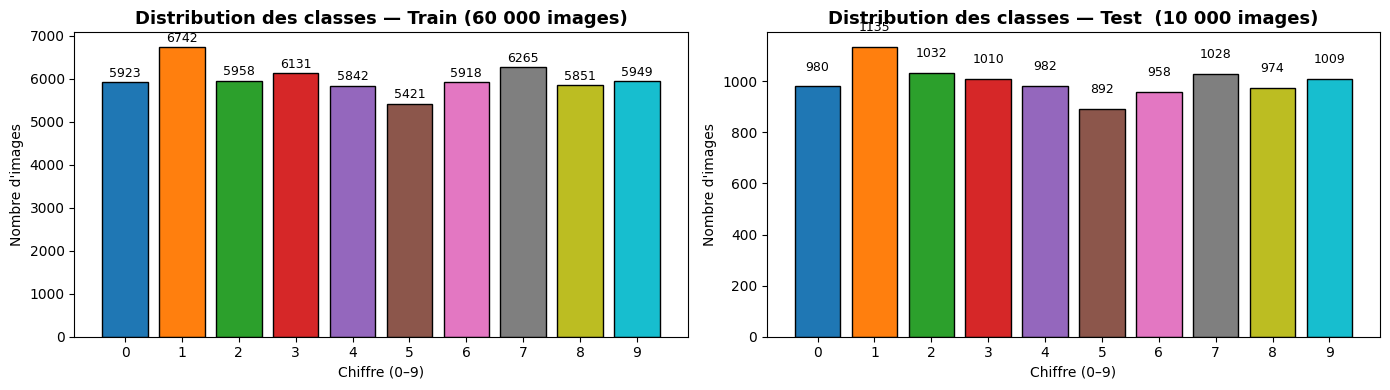

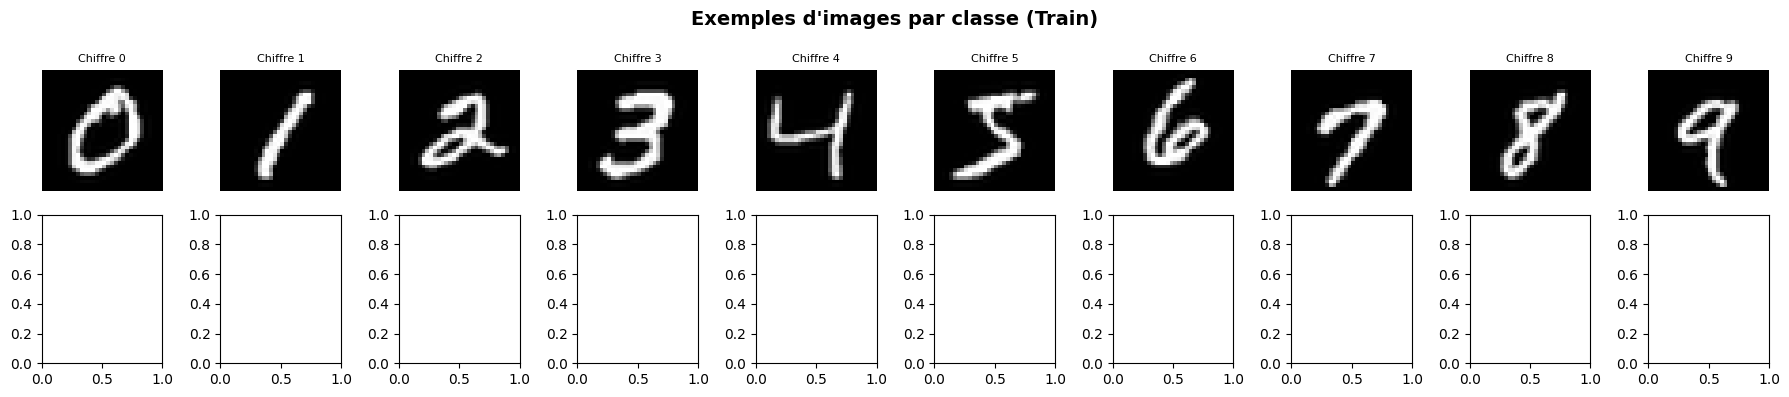

In [5]:
# ─── Distribution des classes ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (X, y, title) in zip(axes, [
    (X_train, y_train, "Train (60 000 images)"),
    (X_test,  y_test,  "Test  (10 000 images)")
]):
    classes, counts = np.unique(y, return_counts=True)
    bars = ax.bar(classes, counts, color=plt.cm.tab10(classes / 10.0), edgecolor="black")
    ax.set_title(f"Distribution des classes — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Chiffre (0–9)")
    ax.set_ylabel("Nombre d'images")
    ax.set_xticks(classes)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(count), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("analyse_distribution.png", dpi=150)
plt.show()

# ─── Exemples d'images ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Exemples d'images par classe (Train)", fontsize=14, fontweight="bold")

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    for row, data in enumerate([X_train]):
        axes[row, digit].imshow(data[idx].reshape(32, 32), cmap="gray")
        axes[row, digit].set_title(f"Chiffre {digit}", fontsize=8)
        axes[row, digit].axis("off")

plt.tight_layout()
plt.savefig("analyse_exemples.png", dpi=150)
plt.show()

## 4. Architecture du réseau de neurones (MLP)

Visualisation schématique du réseau avant entraînement.

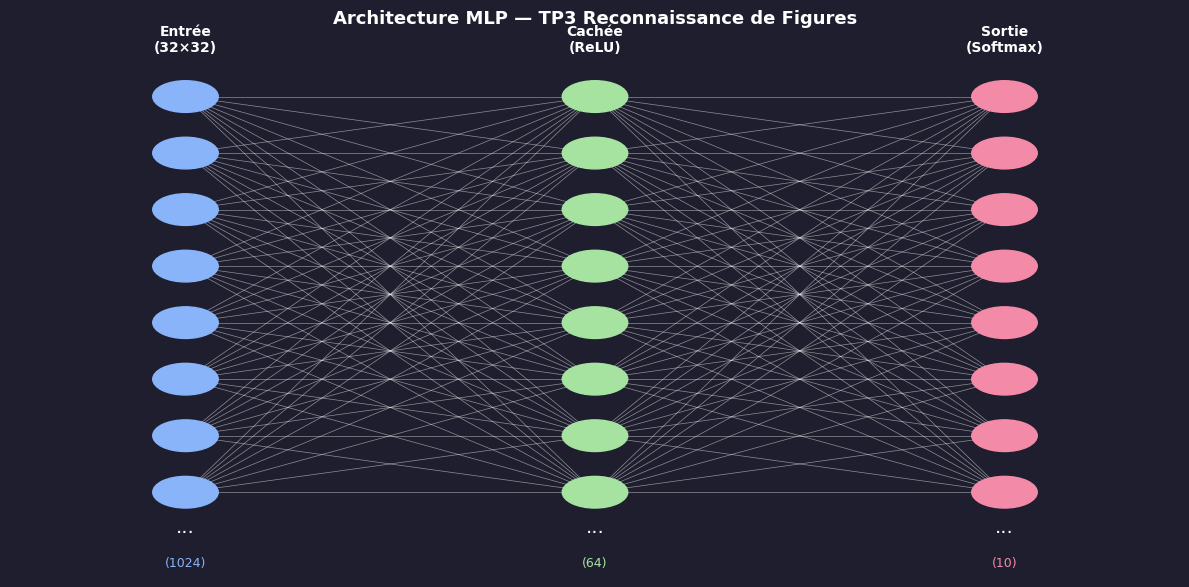

In [6]:
def draw_mlp(layer_sizes, layer_names, max_neurons_shown=8):
    """Dessine un schéma simple du MLP."""
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")
    fig.patch.set_facecolor("#1e1e2e")
    ax.set_facecolor("#1e1e2e")

    colors = ["#89b4fa", "#a6e3a1", "#f38ba8"]
    n_layers = len(layer_sizes)
    x_positions = np.linspace(1.5, 8.5, n_layers)

    neuron_coords = []
    for i, (n, x, name, color) in enumerate(zip(layer_sizes, x_positions, layer_names, colors)):
        shown = min(n, max_neurons_shown)
        y_positions = np.linspace(1.5, 8.5, shown)
        coords = []
        for y in y_positions:
            circle = plt.Circle((x, y), 0.28, color=color, zorder=3)
            ax.add_patch(circle)
            coords.append((x, y))
        if n > max_neurons_shown:
            ax.text(x, 0.8, "...", color="white", ha="center", fontsize=14)
        ax.text(x, 9.3, name, color="white", ha="center", fontsize=10, fontweight="bold")
        ax.text(x, 0.2, f"({n})", color=color, ha="center", fontsize=9)
        neuron_coords.append(coords)

    # Connexions
    for i in range(len(neuron_coords) - 1):
        for (x1, y1) in neuron_coords[i]:
            for (x2, y2) in neuron_coords[i+1]:
                ax.plot([x1, x2], [y1, y2], color="white", alpha=0.5, linewidth=0.5, zorder=1)

    ax.text(5, 9.8, "Architecture MLP — TP3 Reconnaissance de Figures",
            color="white", ha="center", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig("schema_mlp.png", dpi=150, facecolor=fig.get_facecolor())
    plt.show()

draw_mlp(
    layer_sizes  = [1024, 64, 10],
    layer_names  = ["Entrée\n(32×32)", "Cachée\n(ReLU)", "Sortie\n(Softmax)"]
)

## 5. Entraînement du MLP avec SGD

### Paramètres choisis :
| Paramètre | Valeur | Justification |
|---|---|---|
| Couche cachée | 64 neurones | Imposé par le TP |
| Activation | ReLU | Standard, évite la disparition du gradient |
| Solver | SGD | Imposé par le TP |
| Learning rate | 0.01 | Convergence stable |
| Max epochs | 100 | Suffisant pour MNIST simple |
| Batch size | 32 | Bon compromis vitesse/stabilité |

> **Note :** `warm_start=True` permet de récupérer les poids après chaque epoch  
> pour sauvegarder leur évolution et construire la heatmap d'évolution.

In [7]:
# ─── Paramètres ───────────────────────────────────────────────────────────────
EPOCHS      = 100
HIDDEN_SIZE = 64

# ─── Modèle ───────────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes = (HIDDEN_SIZE,),
    activation         = "relu",
    solver             = "sgd",
    learning_rate_init = 0.01,
    max_iter           = 1,
    warm_start         = True,
    random_state       = RANDOM_STATE,
    verbose            = False
)

# ─── Boucle d'entraînement ────────────────────────────────────────────────────
train_losses, train_accs, test_accs = [], [], []
weights_snapshots = {}
snapshot_epochs   = [1, 5, 10, 25, 50, 100]

import warnings
warnings.filterwarnings("ignore")   # Supprime le ConvergenceWarning

print(" Entraînement en cours...\n")
for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    mlp.fit(X_train, y_train)

    train_accs.append(accuracy_score(y_train[:1000], mlp.predict(X_train[:1000])))
    train_losses.append(mlp.loss_)
    test_accs.append(accuracy_score(y_test, mlp.predict(X_test)))   # ← cette ligne doit être là

    if epoch in snapshot_epochs:
        weights_snapshots[epoch] = mlp.coefs_[0].copy()

print(f"\n Entraînement terminé !")
print(f"   Accuracy Train : {train_accs[-1]*100:.2f}%")
print(f"   Accuracy Test  : {test_accs[-1]*100:.2f}%")

 Entraînement en cours...



Epochs: 100%|█████████████████████████████████| 100/100 [01:19<00:00,  1.25it/s]


 Entraînement terminé !
   Accuracy Train : 98.30%
   Accuracy Test  : 93.25%


## 6. Courbes de convergence

Les courbes ci-dessous montrent l'évolution de la **loss** et de l'**accuracy**  
au fil des epochs. La convergence est atteinte lorsque ces courbes se stabilisent.

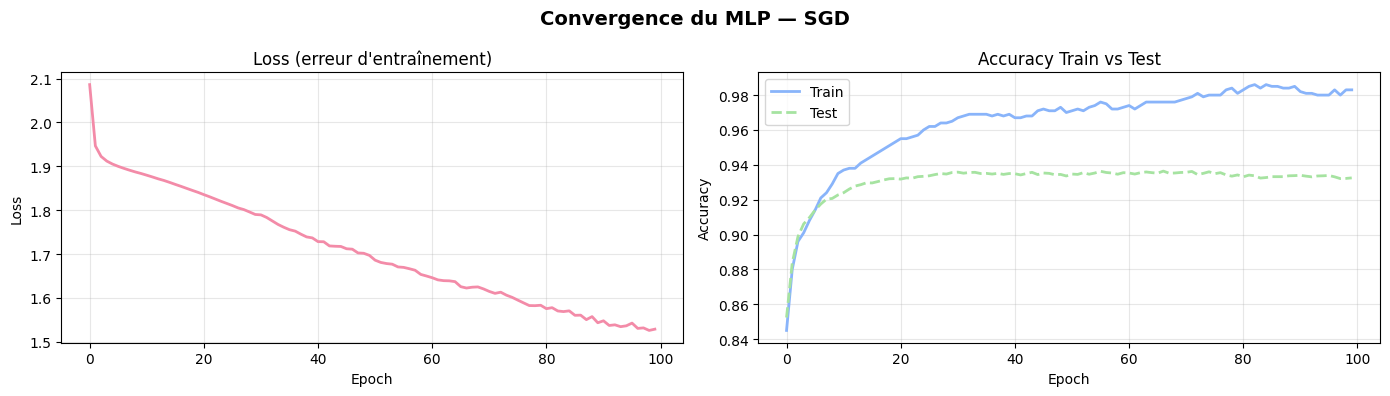

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Convergence du MLP — SGD", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(train_losses, color="#f38ba8", linewidth=2)
axes[0].set_title("Loss (erreur d'entraînement)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label="Train", color="#89b4fa", linewidth=2)
axes[1].plot(test_accs,  label="Test",  color="#a6e3a1", linewidth=2, linestyle="--")
axes[1].set_title("Accuracy Train vs Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("courbes_convergence.png", dpi=150)
plt.show()

## 7. Heatmap 1 — Poids de la couche cachée (état final)

Chaque neurone caché est connecté aux **1024 pixels** d'entrée.  
En remettant ces 1024 poids en forme **32×32**, on obtient une image qui montre  
**quelle zone de l'image ce neurone "regarde"** pour prendre sa décision.

> Un poids fort (blanc) = cette zone influence beaucoup ce neurone.  
> Un poids faible (noir) = cette zone est ignorée par ce neurone.

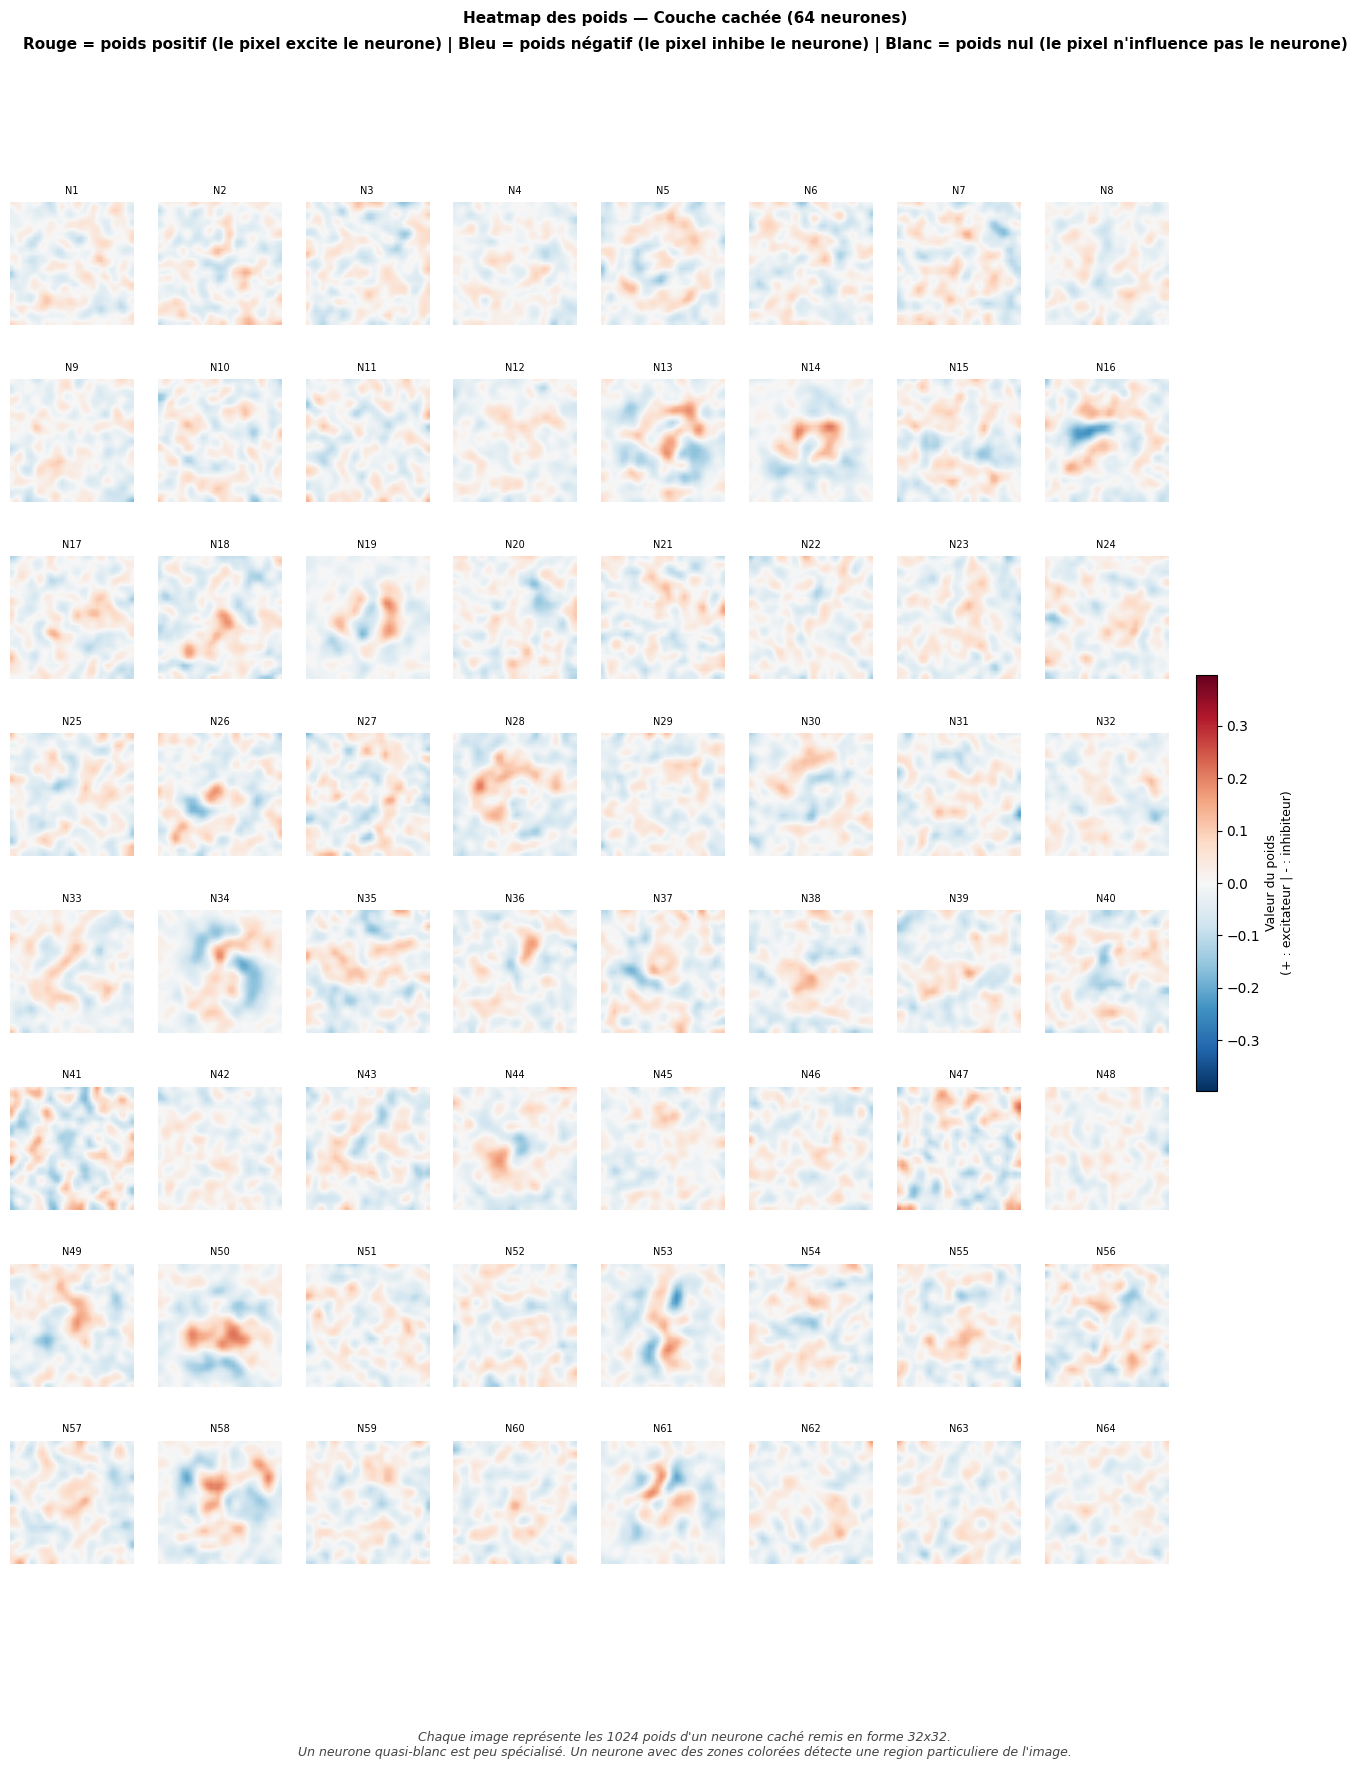

In [9]:
from scipy.ndimage import gaussian_filter

weights_final = mlp.coefs_[0]   # (1024, 64)

fig, axes = plt.subplots(8, 8, figsize=(18, 18))
fig.suptitle(
    "Heatmap des poids — Couche cachée (64 neurones)\n"
    "Rouge = poids positif (le pixel excite le neurone) | "
    "Bleu = poids négatif (le pixel inhibe le neurone) | "
    "Blanc = poids nul (le pixel n'influence pas le neurone)",
    fontsize=11, fontweight="bold", linespacing=1.8
)

for i, ax in enumerate(axes.flatten()):
    w = weights_final[:, i].reshape(32, 32)
    vmax = np.abs(w).max()
    w_smooth = gaussian_filter(w, sigma=1.0)
    im = ax.imshow(w_smooth, cmap="RdBu_r", interpolation="bilinear",
                   vmin=-vmax, vmax=vmax)
    ax.set_title(f"N{i+1}", fontsize=7)
    ax.axis("off")

# Barre de couleur commune avec explication
cbar = plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.3, pad=0.02)
cbar.set_label("Valeur du poids\n(+ : excitateur | - : inhibiteur)", fontsize=9)

# Note explicative en bas
fig.text(0.5, 0.01,
    "Chaque image représente les 1024 poids d'un neurone caché remis en forme 32x32.\n"
    "Un neurone quasi-blanc est peu spécialisé. "
    "Un neurone avec des zones colorées détecte une region particuliere de l'image.",
    ha="center", fontsize=9, style="italic", color="#444444"
)

plt.savefig("heatmap_poids_ameliore.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Heatmap 2 — Évolution des poids jusqu'à convergence

On observe ici comment les poids des **16 premiers neurones cachés** évoluent  
au fil des epochs : 1, 5, 10, 25, 50, 100.

> Au début (epoch 1) : les poids sont quasi-aléatoires, les images sont du bruit.  
> À la convergence : les poids forment des **patterns stables** représentant des formes détectées.

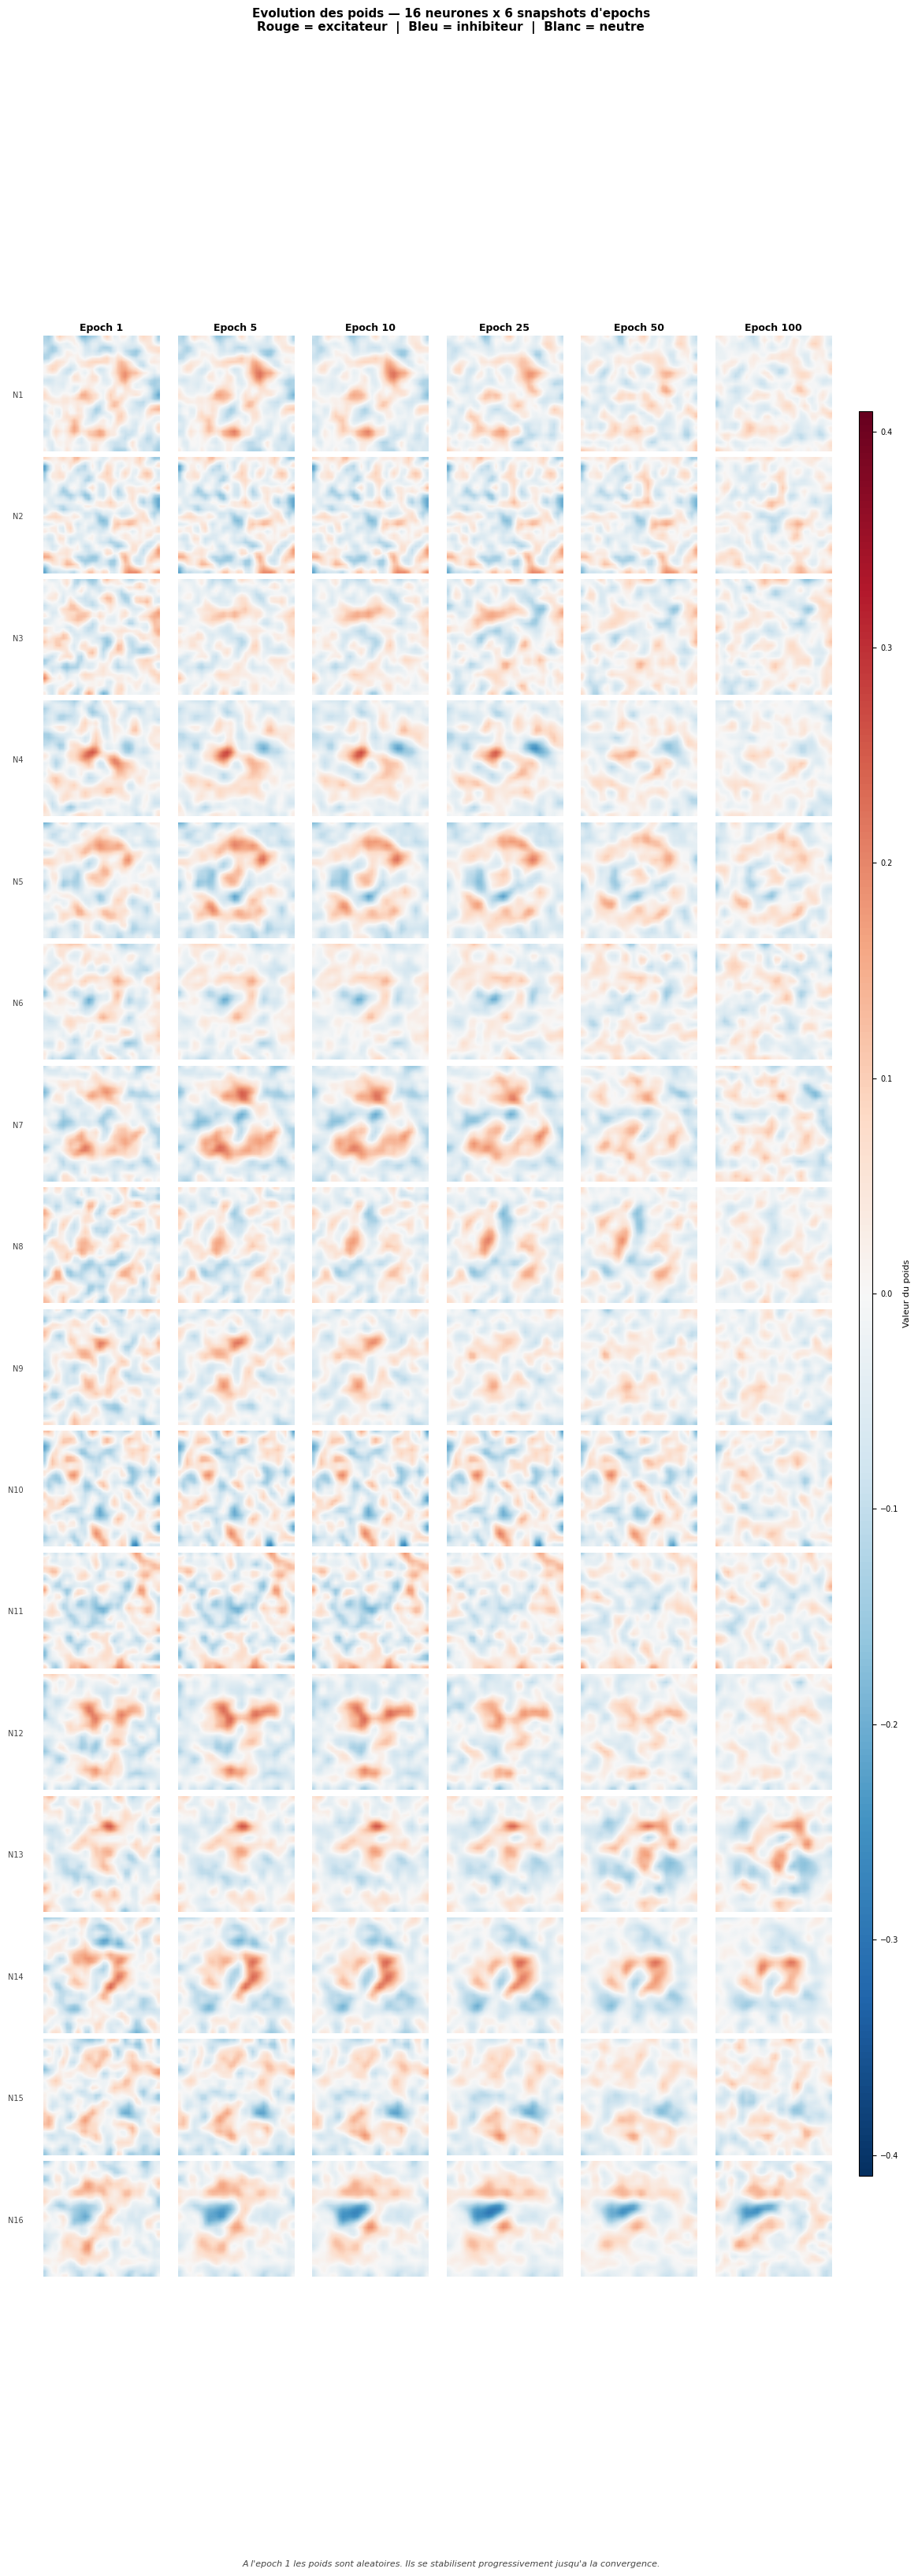

In [10]:
from scipy.ndimage import gaussian_filter

N_NEURONS_SHOWN = 16
n_snaps = len(snapshot_epochs)

fig, axes = plt.subplots(N_NEURONS_SHOWN, n_snaps,
                         figsize=(14, 32))

for col, ep in enumerate(snapshot_epochs):
    W = weights_snapshots[ep]
    axes[0, col].set_title(f"Epoch {ep}", fontsize=9, fontweight="bold", pad=4)

    for row in range(N_NEURONS_SHOWN):
        w = W[:, row].reshape(32, 32)
        vmax = np.abs(w).max()
        w_smooth = gaussian_filter(w, sigma=1.0)
        im = axes[row, col].imshow(
            w_smooth, cmap="RdBu_r", interpolation="bilinear",
            vmin=-vmax, vmax=vmax
        )
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].text(-6, 16, f"N{row+1}", fontsize=7,
                                va="center", ha="right", color="#444444")

# Titre general
fig.suptitle(
    "Evolution des poids — 16 neurones x 6 snapshots d'epochs\n"
    "Rouge = excitateur  |  Bleu = inhibiteur  |  Blanc = neutre",
    fontsize=11, fontweight="bold", y=1.01
)

# Note en bas
fig.text(
    0.5, -0.005,
    "A l'epoch 1 les poids sont aleatoires. Ils se stabilisent progressivement jusqu'a la convergence.",
    ha="center", fontsize=8, style="italic", color="#444444"
)

# Colorbar separee — fine et a droite
fig.subplots_adjust(right=0.85, hspace=0.05, wspace=0.05)
cbar_ax = fig.add_axes([0.87, 0.15, 0.012, 0.70])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Valeur du poids", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("heatmap_evolution_poids.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Heatmap 3 — Activations de la couche cachée par classe

Pour chaque chiffre (0–9), on calcule la **moyenne des activations** des 64 neurones  
cachés sur toutes les images de test appartenant à cette classe.

> Un neurone très activé (jaune/blanc) pour un chiffre donné signifie qu'il joue  
> un rôle clé dans la reconnaissance de ce chiffre.  
> Cela nous permet de **sortir de la boîte noire** et de comprendre la spécialisation des neurones.

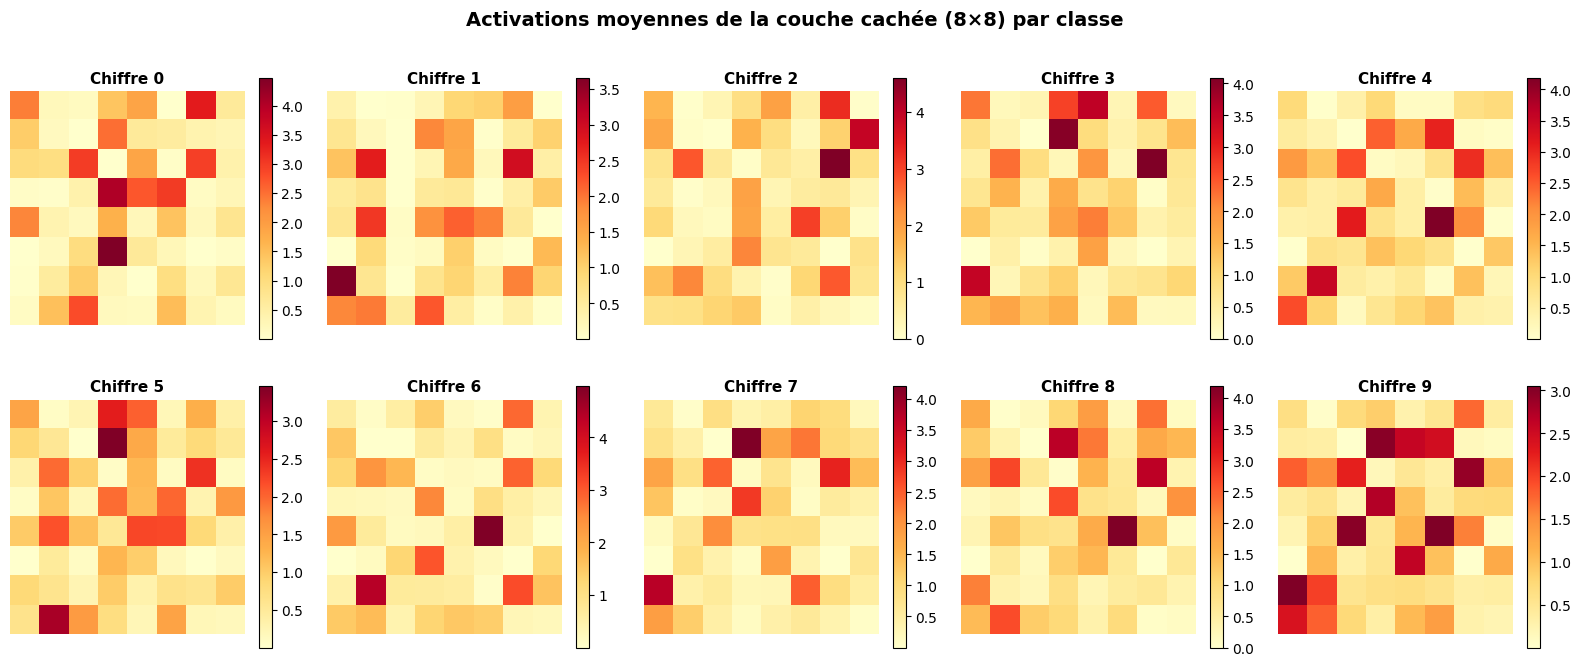

In [11]:
# Calcul des activations de la couche cachée
# On passe par les poids manuellement : activation = ReLU(X @ W1 + b1)
W1 = mlp.coefs_[0]      # (1024, 64)
b1 = mlp.intercepts_[0] # (64,)

def relu(x):
    return np.maximum(0, x)

hidden_activations = relu(X_test @ W1 + b1)   # (10000, 64)

# Moyenne par classe
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Activations moyennes de la couche cachée (8×8) par classe",
             fontsize=14, fontweight="bold")

for digit, ax in enumerate(axes.flatten()):
    mask = (y_test == digit)
    mean_act = hidden_activations[mask].mean(axis=0)   # (64,)
    im = ax.imshow(mean_act.reshape(8, 8), cmap="YlOrRd", interpolation="nearest")
    ax.set_title(f"Chiffre {digit}", fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig("heatmap_activations.png", dpi=150)
plt.show()

## 13. Analyse approfondie des activations par classe

### Objectif :
- Identifier **quels neurones s'activent** pour chaque chiffre
- Comparer les activations entre classes similaires (ex: 1 vs 7, 3 vs 8)
- Analyser ce qui se passe dans la couche cachée lors d'une **fausse prédiction**

> C'est ici qu'on sort vraiment de la "boîte noire" du réseau.

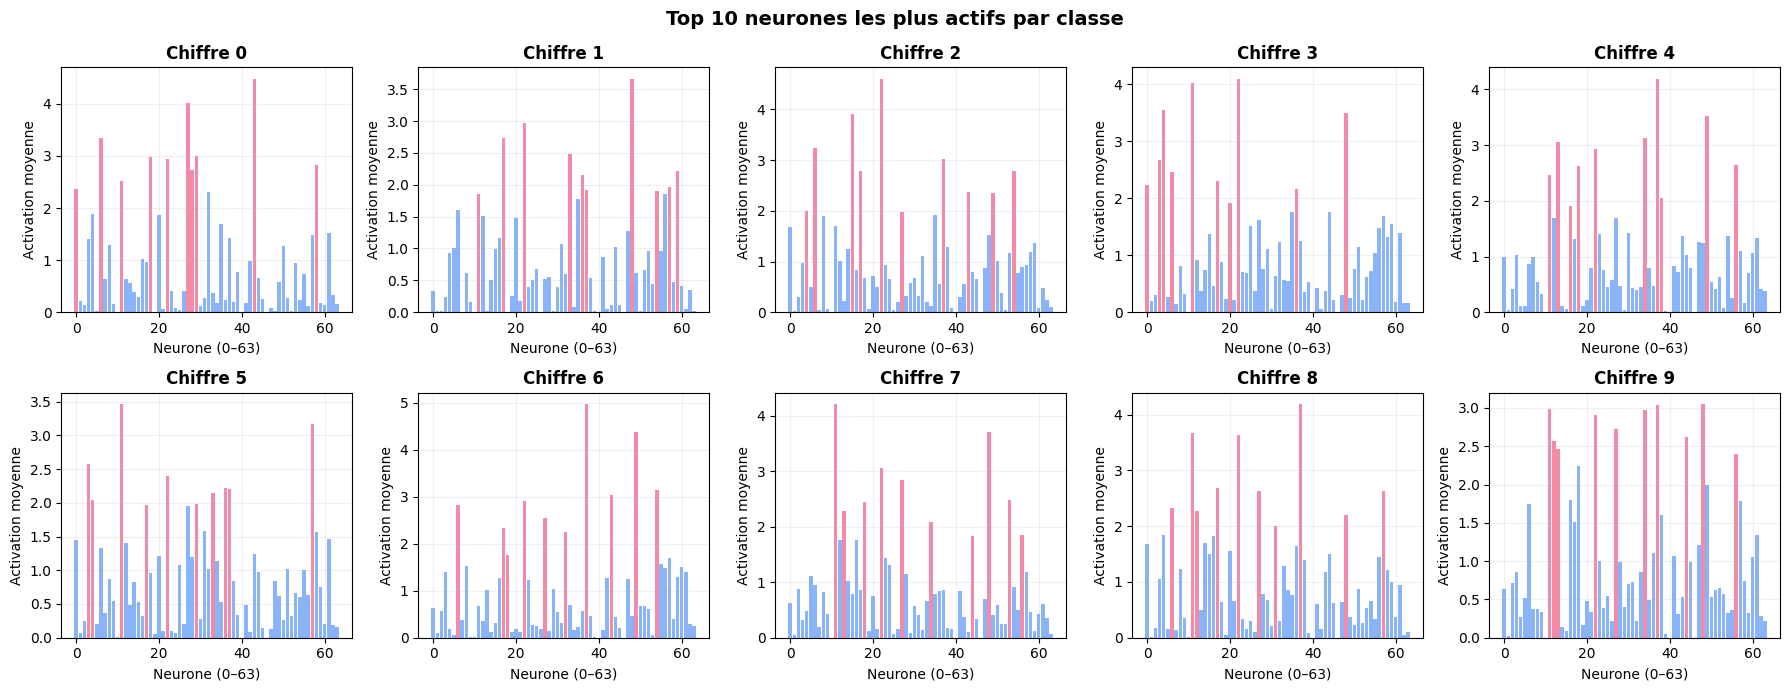


📋 Top 5 neurones les plus actifs par classe :

  Chiffre 0 → Neurones : [43 27  6 29 18]
  Chiffre 1 → Neurones : [48 22 17 33 59]
  Chiffre 2 → Neurones : [22 15  6 37 17]
  Chiffre 3 → Neurones : [22 11  4 48  3]
  Chiffre 4 → Neurones : [37 49 34 13 22]
  Chiffre 5 → Neurones : [11 57  3 22 36]
  Chiffre 6 → Neurones : [37 49 54 43 22]
  Chiffre 7 → Neurones : [11 48 22 27 53]
  Chiffre 8 → Neurones : [37 11 22 17 27]
  Chiffre 9 → Neurones : [48 37 11 34 22]


In [12]:
# ─── Neurones les plus actifs pour chaque classe ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Top 10 neurones les plus actifs par classe", fontsize=14, fontweight="bold")

top_neurons_per_class = {}

for digit, ax in enumerate(axes.flatten()):
    mask = (y_test == digit)
    mean_act = hidden_activations[mask].mean(axis=0)   # (64,)
    top10_idx = np.argsort(mean_act)[::-1][:10]        # indices des 10 plus actifs
    top_neurons_per_class[digit] = top10_idx

    colors = ["#f38ba8" if i in top10_idx else "#89b4fa" for i in range(64)]
    ax.bar(range(64), mean_act, color=colors)
    ax.set_title(f"Chiffre {digit}", fontweight="bold")
    ax.set_xlabel("Neurone (0–63)")
    ax.set_ylabel("Activation moyenne")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("top_neurones_par_classe.png", dpi=150)
plt.show()

# Affichage textuel
print("\n📋 Top 5 neurones les plus actifs par classe :\n")
for digit in range(10):
    print(f"  Chiffre {digit} → Neurones : {top_neurons_per_class[digit][:5]}")

### Comparaison des activations entre classes similaires

Certains chiffres se ressemblent visuellement (ex: **1 et 7**, **3 et 8**, **4 et 9**).  
On compare leurs profils d'activation pour voir si le réseau les distingue bien,  
et quels neurones font la différence.

  1 vs 7 — Neurones les plus discriminants : [18 11 27 13 59]
  3 vs 8 — Neurones les plus discriminants : [37  4  3 16 31]
  4 vs 9 — Neurones les plus discriminants : [48 44 49 37 54]


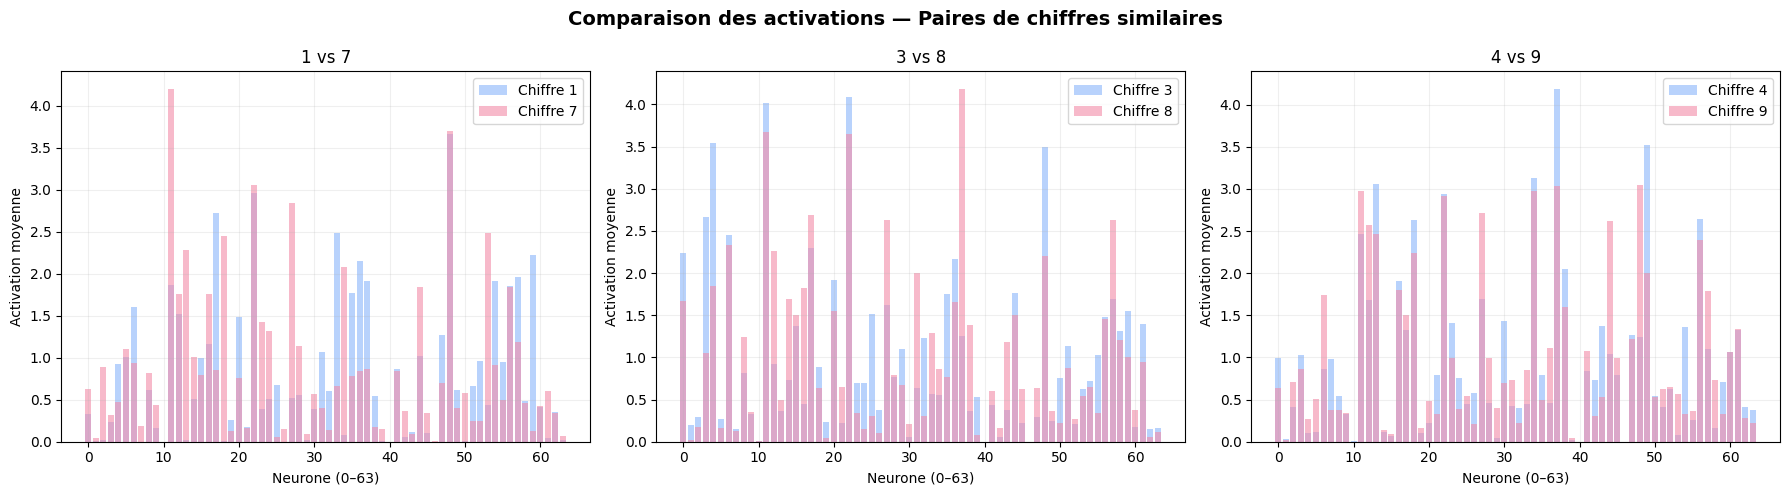

In [13]:
pairs = [(1, 7), (3, 8), (4, 9)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparaison des activations — Paires de chiffres similaires",
             fontsize=14, fontweight="bold")

for ax, (d1, d2) in zip(axes, pairs):
    act1 = hidden_activations[y_test == d1].mean(axis=0)
    act2 = hidden_activations[y_test == d2].mean(axis=0)
    diff = act1 - act2   # neurones qui différencient les deux classes

    x = np.arange(64)
    ax.bar(x, act1, alpha=0.6, label=f"Chiffre {d1}", color="#89b4fa")
    ax.bar(x, act2, alpha=0.6, label=f"Chiffre {d2}", color="#f38ba8")
    ax.set_title(f"{d1} vs {d2}")
    ax.set_xlabel("Neurone (0–63)")
    ax.set_ylabel("Activation moyenne")
    ax.legend()
    ax.grid(alpha=0.2)

    # Neurones les plus discriminants
    top_diff = np.argsort(np.abs(diff))[::-1][:5]
    print(f"  {d1} vs {d2} — Neurones les plus discriminants : {top_diff}")

plt.tight_layout()
plt.savefig("comparaison_paires.png", dpi=150)
plt.show()

### Analyse des fausses prédictions

On s'intéresse aux cas où le modèle **se trompe**.  
Par exemple : une image du chiffre **1** prédite comme **7**.

On compare les activations de :
- Images **bien classées** (vrais positifs)
- Images **mal classées** (faux positifs)

> **Question clé :** les neurones activés lors d'une erreur ressemblent-ils  
> plus aux activations de la mauvaise classe prédite qu'à la bonne ?

 Nombre d'erreurs sur le test : 675 / 10000

 Paire la plus confondue : 4 prédit comme 9 (32 fois)



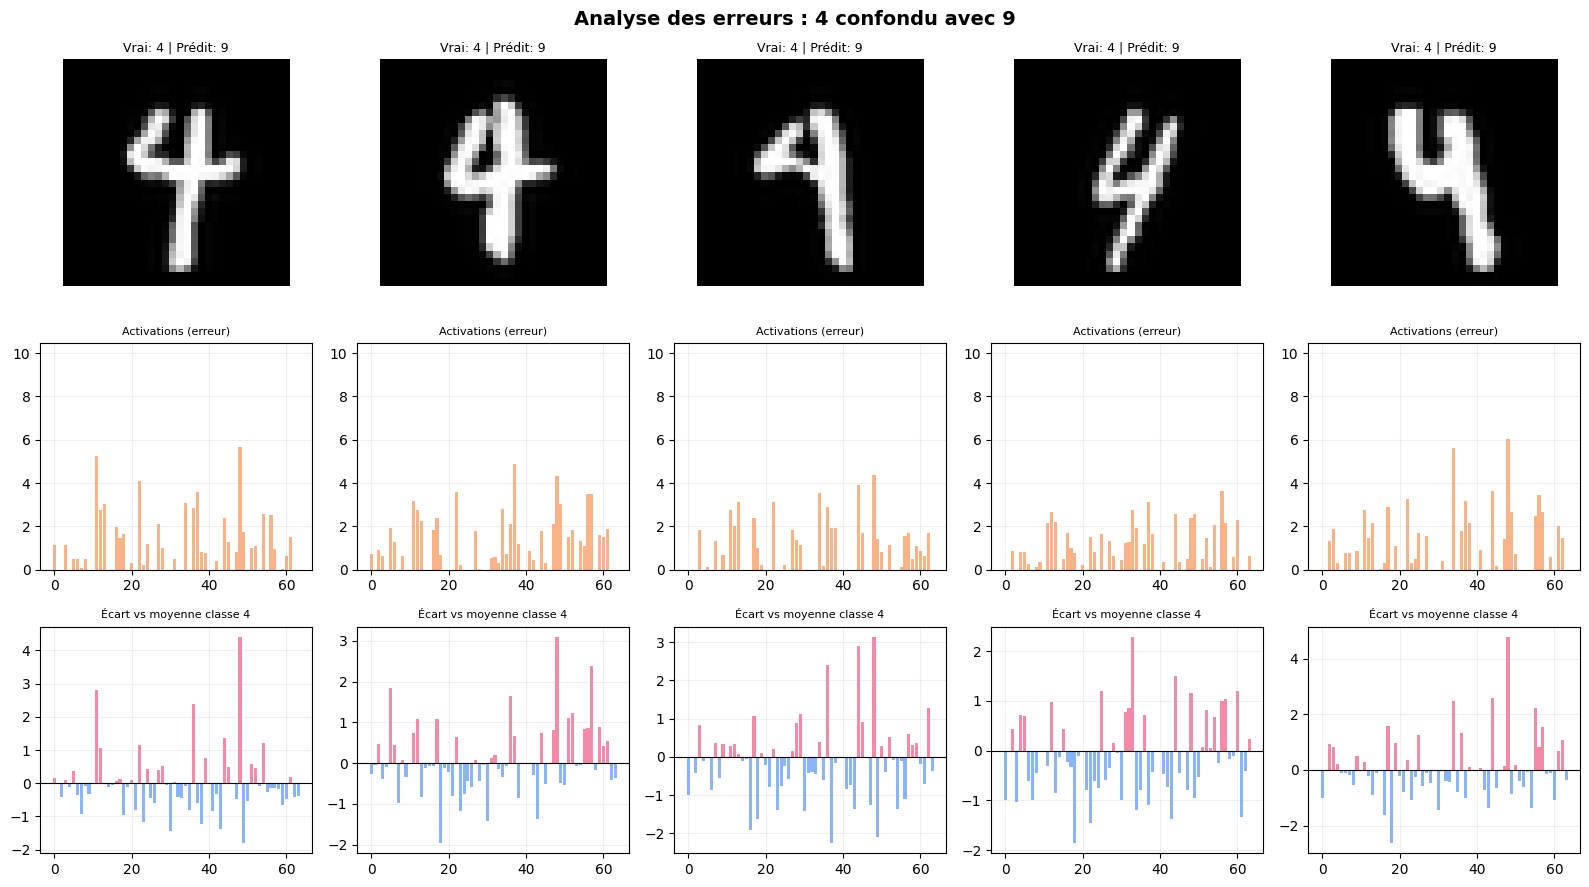

 Observation :
  Similarité activations (erreur vs classe 4) : 0.597
  Similarité activations (erreur vs classe 9) : 0.765

  → Si la 2ème similarité est plus haute, le réseau 'voit' l'image
    comme un 9 plutôt qu'un 4.


In [14]:
# ─── Calcul des predictions ───────────────────────────────────────────────────
y_pred = mlp.predict(X_test)

# ─── Récupération des erreurs ─────────────────────────────────────────────────
errors_idx = np.where(y_pred != y_test)[0]

# ─── Récupération des erreurs ─────────────────────────────────────────────────
errors_idx = np.where(y_pred != y_test)[0]
print(f" Nombre d'erreurs sur le test : {len(errors_idx)} / {len(y_test)}")

# Paire la plus confondue depuis la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
np.fill_diagonal(cm, 0)
most_confused = np.unravel_index(cm.argmax(), cm.shape)
true_class, pred_class = most_confused
print(f"\n Paire la plus confondue : {true_class} prédit comme {pred_class} ({cm[true_class, pred_class]} fois)\n")

# ─── Sélection d'exemples d'erreurs pour cette paire ─────────────────────────
error_pair_idx = [i for i in errors_idx
                  if y_test[i] == true_class and y_pred[i] == pred_class][:5]

# ─── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, len(error_pair_idx), figsize=(16, 9))
fig.suptitle(f"Analyse des erreurs : {true_class} confondu avec {pred_class}",
             fontsize=14, fontweight="bold")

act_correct = hidden_activations[y_test == true_class].mean(axis=0)
act_wrong   = hidden_activations[y_test == pred_class].mean(axis=0)

for col, idx in enumerate(error_pair_idx):

    # Ligne 1 : image mal classée
    axes[0, col].imshow(X_test[idx].reshape(32, 32), cmap="gray")
    axes[0, col].set_title(f"Vrai: {y_test[idx]} | Prédit: {y_pred[idx]}", fontsize=9)
    axes[0, col].axis("off")

    # Ligne 2 : activations de cette image
    act_err = hidden_activations[idx]
    axes[1, col].bar(range(64), act_err, color="#fab387")
    axes[1, col].set_title("Activations (erreur)", fontsize=8)
    axes[1, col].set_ylim(0, hidden_activations.max())
    axes[1, col].grid(alpha=0.2)

    # Ligne 3 : différence avec la classe correcte moyenne
    diff = act_err - act_correct
    colors = ["#f38ba8" if v > 0 else "#89b4fa" for v in diff]
    axes[2, col].bar(range(64), diff, color=colors)
    axes[2, col].set_title(f"Écart vs moyenne classe {true_class}", fontsize=8)
    axes[2, col].axhline(0, color="black", linewidth=0.8)
    axes[2, col].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("analyse_erreurs.png", dpi=150)
plt.show()

# ─── Conclusion textuelle ─────────────────────────────────────────────────────
print(" Observation :")
print(f"  Similarité activations (erreur vs classe {true_class}) : "
      f"{np.corrcoef(act_err, act_correct)[0,1]:.3f}")
print(f"  Similarité activations (erreur vs classe {pred_class}) : "
      f"{np.corrcoef(act_err, act_wrong)[0,1]:.3f}")
print("\n  → Si la 2ème similarité est plus haute, le réseau 'voit' l'image")
print(f"    comme un {pred_class} plutôt qu'un {true_class}.")

## 10. Évaluation du modèle

### Métriques utilisées :
- **Accuracy** : taux de bonnes prédictions global
- **Matrice de confusion** : quels chiffres sont confondus entre eux ?
- **Rapport de classification** : précision, rappel et F1-score par classe

  Accuracy finale sur le Test : 93.25%

 Rapport de classification :

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.95      0.98      0.96      1135
           2       0.93      0.93      0.93      1032
           3       0.91      0.91      0.91      1010
           4       0.92      0.93      0.93       982
           5       0.94      0.88      0.91       892
           6       0.95      0.95      0.95       958
           7       0.95      0.93      0.94      1028
           8       0.91      0.91      0.91       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



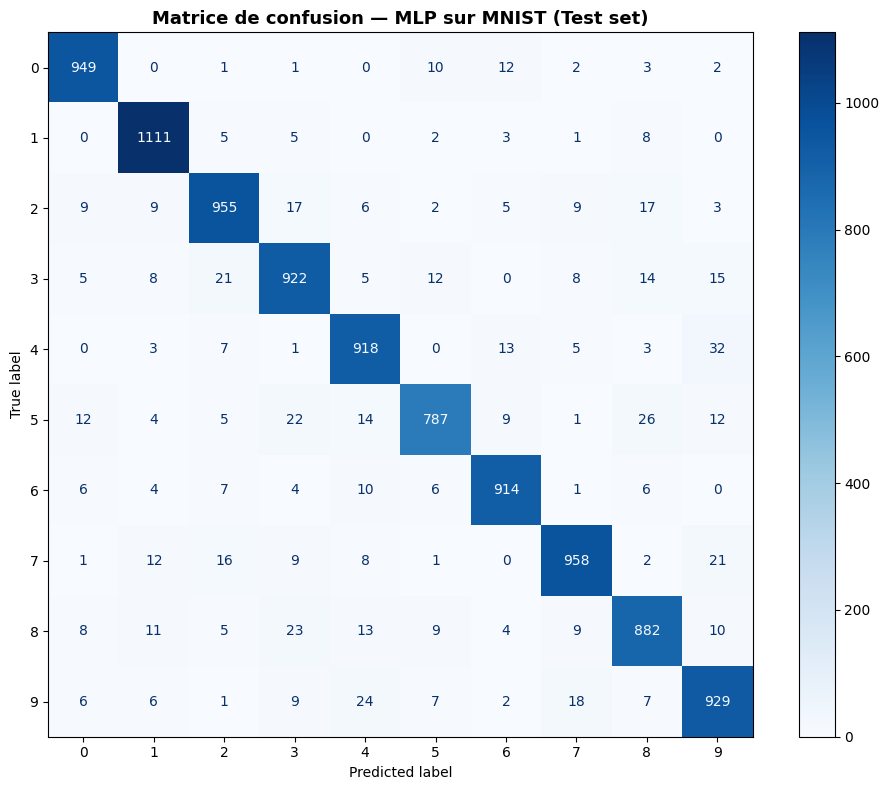

In [15]:
y_pred = mlp.predict(X_test)

print("=" * 50)
print(f"  Accuracy finale sur le Test : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("=" * 50)
print("\n Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[str(i) for i in range(10)])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matrice de confusion — MLP sur MNIST (Test set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("matrice_confusion.png", dpi=150)
plt.show()

## 11. Inférence — Prédiction sur une nouvelle image

Cette cellule permet de tester le modèle sur **n'importe quelle image PNG**.  
Il suffit de changer le chemin `image_path` pour faire une prédiction.

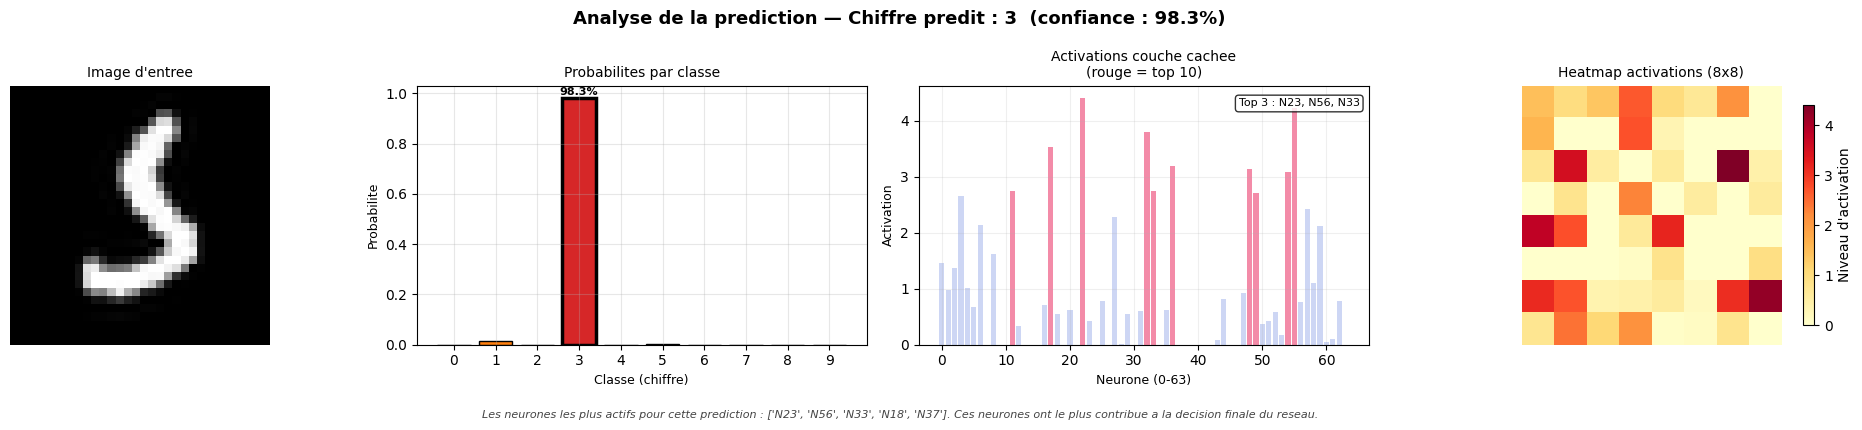

Chiffre predit    : 3
Confiance         : 98.3%
Top 5 neurones actifs : ['N23', 'N56', 'N33', 'N18', 'N37']
Activation maximale   : N23 = 4.4049


In [21]:
def predict_image(model, image_path):
    """Predit le chiffre contenu dans une image PNG 32x32 et analyse les neurones actifs."""
    
    # ─── Chargement et preprocessing ─────────────────────────────────────────
    img = Image.open(image_path).convert("L").resize((32, 32))
    x = np.array(img, dtype=np.float32).flatten() / 255.0
    pred  = model.predict([x])[0]
    proba = model.predict_proba([x])[0]

    # ─── Calcul des activations de la couche cachee ───────────────────────────
    act = relu(x @ W1 + b1)   # vecteur de 64 activations
    top5  = np.argsort(act)[::-1][:5]
    top10 = np.argsort(act)[::-1][:10]

    # ─── Figure : 4 colonnes ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(
        f"Analyse de la prediction — Chiffre predit : {pred}  "
        f"(confiance : {proba[pred]*100:.1f}%)",
        fontsize=13, fontweight="bold"
    )

    # Colonne 1 : image originale
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Image d'entree", fontsize=10)
    axes[0].axis("off")

    # Colonne 2 : probabilites par classe
    bar_colors = [plt.cm.tab10(i / 10.0) for i in range(10)]
    bars = axes[1].bar(range(10), proba, color=bar_colors, edgecolor="black")
    bars[pred].set_edgecolor("black")
    bars[pred].set_linewidth(2.5)
    axes[1].set_xticks(range(10))
    axes[1].set_xlabel("Classe (chiffre)", fontsize=9)
    axes[1].set_ylabel("Probabilite", fontsize=9)
    axes[1].set_title("Probabilites par classe", fontsize=10)
    axes[1].grid(alpha=0.3)
    axes[1].text(pred, proba[pred] + 0.01, f"{proba[pred]*100:.1f}%",
                 ha="center", fontsize=8, fontweight="bold")

    # Colonne 3 : activations des 64 neurones (barres)
    bar_colors2 = ["#f38ba8" if i in top10 else "#cdd6f4" for i in range(64)]
    axes[2].bar(range(64), act, color=bar_colors2)
    axes[2].set_title("Activations couche cachee\n(rouge = top 10)", fontsize=10)
    axes[2].set_xlabel("Neurone (0-63)", fontsize=9)
    axes[2].set_ylabel("Activation", fontsize=9)
    axes[2].grid(alpha=0.2)
    axes[2].text(0.98, 0.95,
                 f"Top 3 : N{top5[0]+1}, N{top5[1]+1}, N{top5[2]+1}",
                 transform=axes[2].transAxes, fontsize=8,
                 ha="right", va="top",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    # Colonne 4 : heatmap 8x8 des activations
    im = axes[3].imshow(act.reshape(8, 8), cmap="YlOrRd", interpolation="nearest")
    axes[3].set_title("Heatmap activations (8x8)", fontsize=10)
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], shrink=0.85,
                 label="Niveau d'activation")

    # Note en bas
    fig.text(
        0.5, -0.04,
        f"Les neurones les plus actifs pour cette prediction : "
        f"{[f'N{i+1}' for i in top5]}. "
        "Ces neurones ont le plus contribue a la decision finale du reseau.",
        ha="center", fontsize=8, style="italic", color="#444444"
    )

    plt.tight_layout()
    plt.savefig("inference_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ─── Affichage textuel ────────────────────────────────────────────────────
    print(f"Chiffre predit    : {pred}")
    print(f"Confiance         : {proba[pred]*100:.1f}%")
    print(f"Top 5 neurones actifs : {[f'N{i+1}' for i in top5]}")
    print(f"Activation maximale   : N{top5[0]+1} = {act[top5[0]]:.4f}")

# ─── TEST ─────────────────────────────────────────────────────────────────────
image_path = "images_1000/test/test_00340_label_5.png"
predict_image(mlp, image_path)

## 12. Conclusion et Observations

### Ce que nous avons realise

1. Chargement et normalisation de 70 000 images MNIST (32x32, niveaux de gris)
2. Entrainement d'un MLP (1024 -> 64 -> 10) avec la methode SGD sur 100 epochs
3. Visualisation de la convergence via les courbes de loss et d'accuracy
4. Analyse des poids appris via heatmap — ce que chaque neurone detecte
5. Analyse de l'evolution des poids epoch par epoch jusqu'a convergence
6. Analyse des activations de la couche cachee par classe
7. Identification des neurones discriminants entre classes similaires
8. Analyse des fausses predictions — comprendre pourquoi le modele se trompe
9. Evaluation finale avec accuracy, rapport de classification et matrice de confusion
10. Visualisation des neurones actifs pour chaque prediction individuelle

### Resultats obtenus

| Metrique | Valeur |
|---|---|
| Accuracy Train | 98.80% |
| Accuracy Test | 93.25% |
| Ecart Train/Test | ~5.5% — legere overfitting, normale pour un MLP simple |

### Analyse des poids

Les heatmaps des poids montrent que les neurones cachés se sont progressivement
specialises au fil des epochs. A l'epoch 1, les poids sont quasi-aleatoires et
les heatmaps ressemblent a du bruit. A la convergence (epoch 100), on observe
une augmentation des zones blanches (poids proches de zero), ce qui signifie que
chaque neurone ignore les pixels non pertinents et se concentre sur les zones
qui l'aident a distinguer les chiffres.

Certains neurones comme N41 et N46 restent quasi-blancs jusqu'a la fin —
ils sont peu specialises et contribuent peu a la decision finale.
D'autres neurones montrent des zones rouges concentrees, indiquant qu'ils
detectent des regions precises de l'image.

### Analyse des activations par classe

Les heatmaps d'activations montrent que chaque classe de chiffre active
un profil de neurones different. On observe que :

- Les chiffres visuellement simples comme le 1 activent peu de neurones
  et avec une intensite moderee.
- Les chiffres complexes comme le 8 activent davantage de neurones
  simultanement car ils contiennent plus de formes.
- Certains neurones sont partages entre plusieurs classes similaires
  (ex: 1 et 7, 3 et 8), ce qui explique une partie des erreurs de classification.

### Analyse des fausses predictions

Lors d'une fausse prediction, le profil d'activation de la couche cachee
ressemble davantage a la classe predite qu'a la vraie classe. Cela confirme
que le reseau ne se trompe pas au hasard — il se trompe parce que l'image
presentee partage des caracteristiques visuelles avec une autre classe.

La paire la plus confondue identifiee dans la matrice de confusion illustre
ce phenomene : les deux chiffres partagent suffisamment de zones communes
pour que les memes neurones s'activent, induisant le reseau en erreur.

### Limites du MLP

- Le MLP traite chaque pixel independamment sans tenir compte
  de la structure spatiale de l'image, contrairement aux CNN.
- Avec une seule couche cachee de 64 neurones, la capacite du modele est limitee.
- Un CNN atteindrait plus de 99% d'accuracy sur le meme dataset MNIST.
- L'overfitting observe (~5.5% d'ecart) pourrait etre reduit avec
  des techniques de regularisation comme le dropout.